In [1]:
from antares_devkit.models import BaseFilter
from antares_devkit.models import DevKitLocus
from antares_client import search
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import pandas as pd

t_now = Time.now().mjd

In [26]:
# q_lsst = {
#     "query": {
#         "exists": [
#                 {"field": "properties.survey.lsst"}
#              ],
#         "filter": [
#                 {"range": {"properties.newest_alert_observation_time": {"gte": t_now-150}}}
#              ],
#         }
#     }

q_lsst = {
    "query": {
        "bool": {
            "filter": [
                { "range": { "properties.newest_alert_observation_time": { "gte": t_now-50} } },
                { "exists": { "field": "properties.survey.lsst" } },
             ]
        }
    }
}


In [27]:
q_lsst = list(search.search(q_lsst))

In [28]:
len(q_lsst)

10000

In [5]:
oid1_dev = q_lsst[0].to_devkit()
oid1_locus = DevKitLocus.model_validate(oid1_dev)

In [6]:
oid1_dev

{'id': 'ANT2026219nt49mrued',
 'ra': 251.20016351867503,
 'dec': -23.529163978321492,
 'user_tags': ['lsst_scimma_quality_transient'],
 'old_properties': {'num_alerts': 2,
  'num_mag_values': 2,
  'brightest_alert_id': 'lsst:170455191001235851',
  'brightest_alert_magnitude': 21.58473826034249,
  'brightest_alert_observation_time': 61187.396850601,
  'newest_alert_id': 'lsst:170455191001235851',
  'newest_alert_magnitude': 21.58473826034249,
  'newest_alert_observation_time': 61187.396850601,
  'oldest_alert_id': 'lsst:170455190789948541',
  'oldest_alert_magnitude': 21.712754210382396,
  'oldest_alert_observation_time': 61187.39629700195,
  'is_corrected': 'true',
  'survey': {'ztf': {'id': [], 'rcid': [], 'field': [], 'ssnamenr': []},
   'lsst': {'dia_object_id': ['170455190789948541'], 'ss_object_id': []}}},
 'catalog_objects': {},
 'grav_wave_events_metadata': {},
 'alerts': [{'id': 'lsst:170455190789948541',
   'mjd': 61187.39629700195,
   'properties': {'lsst_observation_reason':

In [31]:
oid1_dev["old_properties"]["feature_excess_variance_flux_g"]

0.05641647586825648

In [96]:
# for a in q_lsst[:1000]:
def check_var(ant_client_id):
    oid_now_dev = ant_client_id.to_devkit()
    oid_now_locus = DevKitLocus.model_validate(oid_now_dev)
    
    lc_1 = {'g': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}, 
            'r': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}, 
            'i': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}, 
            'z': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}, 
            'u': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}, 
            'y': {'ant_mjd': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': [], 'lsst_diaSource_snr': [], 'observations' : 0, 'variance' : 0}}
        
    for alert in oid_now_locus.alerts:
        if alert.properties["ant_survey"] == 4:
            band = alert.properties['ant_passband']
            lc_1[band]['ant_mjd'].append(alert.properties['ant_mjd'])
            lc_1[band]['lsst_diaSource_scienceFlux'].append(alert.properties['lsst_diaSource_scienceFlux'])
            lc_1[band]['lsst_diaSource_scienceFluxErr'].append(alert.properties['lsst_diaSource_scienceFluxErr'])
            lc_1[band]['lsst_diaSource_snr'].append(alert.properties['lsst_diaSource_snr'])
            lc_1[band]['observations'] += 1
    
    for band in lc_1: 
        if lc_1[band]['observations'] > 5:
            lc_1[band]['variance'] = np.var(lc_1[band]['lsst_diaSource_scienceFlux'])

    return lc_1
    

In [115]:
for a in q_lsst[3000:4000]:
    b = check_var(a)
    for band in b:
        if b[band]['variance'] != 0:
            print(b)
            

In [119]:
lc

alert_id,ant_mjd,ant_survey,ant_ra,ant_dec,ant_passband,ant_mag,ant_magerr,ant_maglim,ant_mag_corrected,ant_magerr_corrected,ant_magulim_corrected,ant_magllim_corrected
str42,float64,int64,float64,float64,str1,float64,float64,float64,float64,float64,float64,float64
ztf_upper_limit:ZTF18ablpehf-550425250215,58304.42525460012,2,--,--,g,--,--,20.06410026550293,--,--,--,--
ztf_upper_limit:ZTF18ablpehf-566252500215,58320.252499999944,2,--,--,R,--,--,19.881200790405273,--,--,--,--
ztf_upper_limit:ZTF18ablpehf-567189090215,58321.189097200055,2,--,--,g,--,--,18.963199615478516,--,--,--,--
ztf_upper_limit:ZTF18ablpehf-567272245615,58321.27224540012,2,--,--,R,--,--,19.17329978942871,--,--,--,--
ztf_upper_limit:ZTF18ablpehf-567273650215,58321.27365740016,2,--,--,R,--,--,20.10379981994629,--,--,--,--
ztf_candidate:580338315615015004,58334.33831019979,1,283.2910358,-13.4901669,R,17.44230079650879,0.1050110012292862,19.719999313354492,--,--,--,--
ztf_candidate:580338760215015013,58334.3387616002,1,283.2910166,-13.4901862,R,17.50415802001953,0.08335761725902557,20.084213256835938,--,--,--,--
ztf_upper_limit:ZTF18ablpehf-581290670215,58335.29067130014,2,--,--,g,--,--,20.196199417114258,--,--,--,--
ztf_candidate:582227990215015022,58336.22799770022,1,283.2910803,-13.4901952,R,16.992799758911133,0.04529700055718422,20.216100692749023,--,--,--,--


In [30]:
oids = {}
for ant_id in q_lsst:
    oid_dev = ant_id.to_devkit()
    oid_locus = DevKitLocus.model_validate(oid_dev)
    lsst_exists = 0
    
    for alert in oid_locus.alerts:
        if 'lsst_diaSource_diaSourceId' in alert.properties:
            if lsst_exists == 0:
                oids[oid_dev['id']] = [alert]
                lsst_exists = 1
            else:
                oids[oid_dev['id']].append(alert)

In [ ]:
oids = {}
i = 0
for ant_id in q_lsst:
    oid_dev = ant_id.to_devkit()
    oid_locus = DevKitLocus.model_validate(oid_dev)
    lsst_alerts = []
    
    for alert in oid_locus.alerts:
        if 'lsst_diaSource_diaSourceId' in alert.properties:
            lsst_alerts.append(alert)
    i += 1 
    if len(lsst_alerts) > 2:
        oids[oid_dev['id']] = lsst_alerts
        print(i, oid_dev['id'], len(oids[oid_dev['id']]))

the oids dict contains all the alerts from lsst detections for each locus obtained from the q_lsst query at the beginning, seperated by antares id

In [25]:
oids['ANT2026gixl0yuj4zkt']

[DevkitAlert(id='lsst:170446320866689097', mjd=61185.078459522134, properties={'lsst_observation_reason': 'triplet_pairs_iz_33.0', 'lsst_target_name': 'bulgy', 'lsst_diaSource_diaSourceId': 170446320866689097, 'lsst_diaSource_visit': 2026052400211, 'lsst_diaSource_detector': 17, 'lsst_diaSource_diaObjectId': 170446320866689097, 'lsst_diaSource_ssObjectId': 0, 'lsst_diaSource_parentDiaSourceId': 0, 'lsst_diaSource_midpointMjdTai': 61185.078459522134, 'lsst_diaSource_ra': 251.321883761223, 'lsst_diaSource_raErr': 8.580495887144934e-06, 'lsst_diaSource_dec': -23.729428839117414, 'lsst_diaSource_decErr': 9.237390258931555e-06, 'lsst_diaSource_ra_dec_Cov': 2.031988119433059e-11, 'lsst_diaSource_x': 2762.04443359375, 'lsst_diaSource_xErr': 0.13751399517059326, 'lsst_diaSource_y': 231.39149475097656, 'lsst_diaSource_yErr': 0.18077805638313293, 'lsst_diaSource_centroid_flag': False, 'lsst_diaSource_apFlux': 15503.625, 'lsst_diaSource_apFluxErr': 859.9581298828125, 'lsst_diaSource_apFlux_flag':

In [212]:
# mag_var = []
# mag_keys = []
# for key, alerts in oids.items():
#     alert_num = len(alerts)
#     if alert_num > 2:
#         mags = []
#         for alert in alerts:
#             m = -2.5 * np.log10(alert.properties['lsst_diaSource_scienceFlux']) + 31.4
#             mags.append(m)
#         var = float(np.var(mags))
#         mag_var.append(var)
#         mag_keys.append(key)

(array([138.,   7.,   2.,   3.,   1.,   0.,   0.,   0.,   1.,   1.]),
 array([1.19809119e-05, 5.12448454e-02, 1.02477710e-01, 1.53710574e-01,
        2.04943439e-01, 2.56176303e-01, 3.07409168e-01, 3.58642032e-01,
        4.09874897e-01, 4.61107761e-01, 5.12340626e-01]),
 <BarContainer object of 10 artists>)

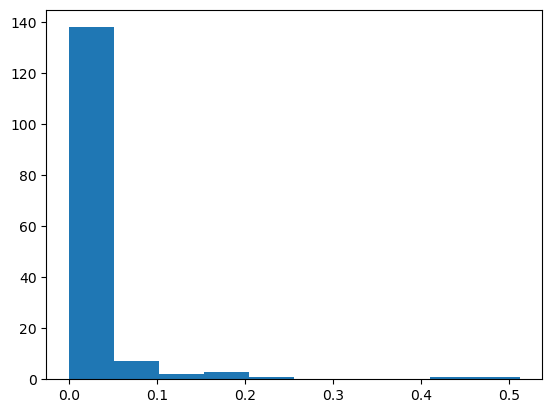

In [213]:
# plt.hist(mag_var)
# plt.semilogy()

In [1]:
# for (x, oid) in zip(mag_var, mag_keys):
#     if x > 0.05:
#         print(x, oid, oids[oid][-1].properties['lsst_diaObject_nDiaSources'])

NameError: name 'mag_var' is not defined

In [31]:
snr_s = []
mag_s = []
temp_mag_s = []
band_s = []
snr_keys = []
for key, alerts in oids.items():
    alert_num = len(alerts)
    if alert_num > 2:
        snr = []
        mag = []
        temp_mag = []
        band = []
        for alert in alerts:
            here_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_scienceFlux']) + 31.4)
            here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)
            
            snr.append(alert.properties['lsst_diaSource_snr'])
            mag.append(here_mag)
            temp_mag.append(here_temp_mag)
            band.append(alert.properties['ant_passband'])
        
        snr_s.append(snr)
        mag_s.append(mag)
        temp_mag_s.append(temp_mag)
        snr_keys.append(key)
        band_s.append(band)

this seperates the information in the oids dict, pulling the associated SNR in the difference image, science mag, template mag, and bands for each object (according to antares id)

In [35]:
band_s

[['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['i', 'r', 'r'],
 ['z', 'r', 'r'],
 ['r', 'r', 'r'],
 ['z', 'r', 'r'],
 ['z', 'r', 'r']]

In [38]:
dif_s = []
var_s = []
hyper_v_s = []
i = 0
while i < len(snr_s):
    check = band_s[i].count('r') == len(band_s[i])
    if check == False:
        i += 1
    else:
        dif = []
        for mag, temp in zip(mag_s[i], temp_mag_s[i]):
            dif.append(temp - mag)
        
        dif = float(abs(np.median(dif)))
        var = float(np.var(mag_s[i]))
        hyper_v = float(np.sqrt(dif**2 + (4*var)**2))

        dif_s.append(dif)
        var_s.append(var)
        hyper_v_s.append(hyper_v)
        
        
        # if hyper_v > 1.5:
        print(f'{snr_keys[i], snr_s[i], mag_s[i], dif, var, dif/var, hyper_v}\n')
        i += 1

('ANT2026idvwgltu1upx', [10.673392295837402, 12.140336990356445, 15.297110557556152], [19.88621962390605, 19.772070827217664, 19.75685304223816], 0.13681433825199818, 0.0033330268019471504, 41.04807623271178, 0.1374623884338263)



In [42]:
oid_mags = {}
for key, alerts in oids.items():
    oid_mags[key] = {'mag': [], 'temp_mag': [], 'dif_mag': [], 'variance': 0, 'hyper_V': 0, 'band': [], 'snr' : []}

    for alert in alerts:
        here_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_scienceFlux']) + 31.4)
        here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)
        here_dif_mag = float(here_temp_mag - here_mag)
        
        oid_mags[key]['mag'].append(here_mag)
        oid_mags[key]['temp_mag'].append(here_temp_mag)
        oid_mags[key]['dif_mag'].append(here_dif_mag)
        oid_mags[key]['band'].append(alert.properties['ant_passband'])
        oid_mags[key]['snr'].append(alert.properties['lsst_diaSource_snr'])

    here_var = float(np.var(oid_mags[key]['mag']))
    here_difs = float(np.median(oid_mags[key]['dif_mag']))
    here_V = float(np.sqrt(here_difs**2 + (4*here_var)**2))
    
    oid_mags[key]['hyper_V'] = here_V
    oid_mags[key]['variance'] = here_var

    if here_V > 1.5:
        print(f"{key}: hypervariance V: {oid_mags[key]['hyper_V']}, variance: {oid_mags[key]['variance']}\nmags: {oid_mags[key]['mag']}, template mags: {oid_mags[key]['temp_mag']}\n")

        

ANT2024pkpb03myqgeh: hypervariance V: 2.9428036773750312, variance: 0.3403501965444064
mags: [18.606546411947534, 19.803682678762286, 19.880928464608914], template mags: [20.193258592658495, 22.412644423013617, 22.493462535612274]

ANT2024oxfkhcie1y4t: hypervariance V: 1.9215215966694439, variance: 0.47851286650348007
mags: [19.778216646393723, 20.846304832442932, 20.804633488825523, 20.804451519655665, 20.78318195974871, 20.810131797349516, 20.823801732604643, 20.818111589462546, 20.827815257891828, 20.802056781794885, 20.801219271236853, 20.795614964401274, 20.8017777027897, 23.082361847027457, 19.583004388533382, 19.771940444343933, 19.585540328555467, 21.761812503247782, 21.73573189880228, 21.796712018204435, 21.819601873134765, 21.763578604300804, 21.752503123042747, 21.721757638395157, 21.75963469490291, 21.70038498563494, 21.84232639219902, 21.752041634367973, 21.880384585028345, 21.73042839587901, 20.85838433345777, 20.78649392015861, 20.815874638076416, 20.798593243051723, 20.

KeyError: 'lsst_diaSource_scienceFlux'

here, im looking at the difference mag (template mag - science mag), variance of the science mag, and made a temporary version of Morganson et al (2015)'s V threshold for hypervariables. i used 4 as the coefficient next to the variance as (in general) the difference mag is a little over 3 times larger than the variance (with outliers for a larger difference), in a similar manner that Morgaonson et al. (2015) chose 2 for their coefficient. i am only using observations in the r band, as that is what the majority of lsst alert observations were taking in. an issue i see is that the template mag fluctuates but im unsure why, since i just use the 'lsst_diaSource_templateFlux' property in the alerts to determine the magnitude in the template images. i can also see in the snapshot images on antares that the template images do seem to be different for the different alerts? im not really sure why that is,,,, something to look into

Morganson et al had their threshold at 2, i tried 2, 1.5, and 1. i looked at their magnitudes, their SNR from the difference images, how intense the median mag difference is, how much each varies, and pulled the snapshot images from antares for each object that passed each threshold. 
- 1 threshold included many objects that only varied by less than 7%
- 1.5 threshold included objects of case 1 or 2:
    - medium (~ 1.4-2.1) mag difference with high variance (~ 20-51%)
    - high mag difference (~ 3.1) with low variance (~ 1%) ([ANT2026hod0p817t93a](https://antares.noirlab.edu/loci/ANT2026hod0p817t93a) - this object has low variance but in viewing the snapshots, it is clear that this IS a transient, having no presence in the template images yet being fairly bright in the science images
- 2 threshold excluded [ANT20260eoaoz804h0y](https://antares.noirlab.edu/loci/ANT20260eoaoz804h0y), an object with 1.4 mag change and 20% variance (v similar values to others, but none have this specific combination, others have one of 2 variables within V be greater by a significant amount)

of the objects that passed through this simple filter, only 3 have magnitudes bright enough to be viewed by SDSS (being btwn 20-22 mag), the other 2 have mag > 22 and thus are far too dim to be observed by SDSS

there are a few interesting things about the objects that were able to pass through the filter:
- they all seem to be objects that appeared since the template images were created (as opposed to disappearing objects)
- they all only have lsst measurements (from what i can see in the antares explore GUI) even though they are in the range of ZTF and ZTF has observed in that part of the sky. (might be the objects are too dim/weren't visible when ZTF observed that part of the sky)

one of the objects, [ANT20260eoaoz804h0y](https://antares.noirlab.edu/loci/ANT20260eoaoz804h0y), also exhibits a strange shape, being oblong as opposed to elliptical like the other objects. 

of the 10,000 sample objects obtained from the simple query, 7888 objects had at least 1 alert with an associated lsst diaSource id. of the 7888 objects, only 153 objects had 3 observations by lsst in the r band. of these 153 objects, only 5 pass a 1.5 V threshold. of those 5 objects, only 3 have magnitudes that are brighter that 22 mag in the majority of their observations. this is a 0.03% trigger percentage. 

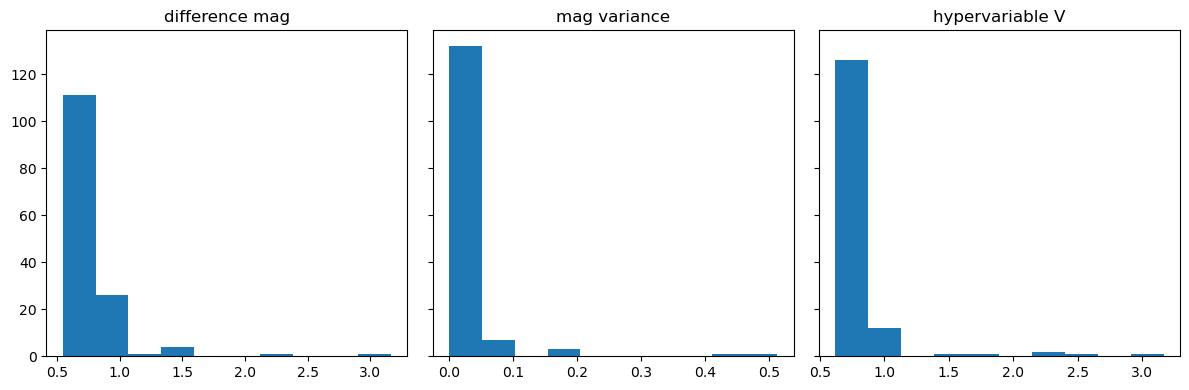

In [303]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
ax[0].hist(dif_s)
ax[0].title.set_text('difference mag')

ax[1].hist(var_s)
ax[1].title.set_text('mag variance')

ax[2].hist(hyper_v_s)
ax[2].title.set_text('hypervariable V')

plt.tight_layout()